# Cassava Leaf Disease Image Classification-MobileNetV2

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*JMMAN8_qmtIUakWEg-ouzw.jpeg" width="400">

## Project Aim

This study aims to automate the diagnosis of viral and bacterial pathogens in Manihot esculenta (Cassava) plants, a staple crop for global food security, by leveraging Convolutional Neural Network (CNN) architectures. The primary objective is to develop a high-generalization classification model capable of accurately distinguishing critical diseases such as Cassava Mosaic Disease (CMD) and Cassava Brown Streak Disease (CBSD) from low-resolution, noisy, and field-acquired images. By employing deep learning-based feature extraction techniques, the project intends to establish a robust digital decision-support mechanism to mitigate crop yield losses and enhance agricultural sustainability.

## Importing Libraries

In [20]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"zynptkn06","key":"16916ef9ce1a086876f1cb418ad605e3"}'}

In [26]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [27]:
# Verileri indir (zip olarak iner)
!kaggle competitions download -c cassava-leaf-disease-classification

# İnen dosyaları zipten çıkar
!unzip -q cassava-leaf-disease-classification.zip

cassava-leaf-disease-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace label_num_to_disease_map.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [29]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Flatten, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Input)
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## Reading Dataset

In [30]:
path = './'
df = pd.read_csv('train.csv')

In [31]:
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [32]:
df['image_id'] = path + 'train_images/' + df['image_id']
df['label'] = df['label'].astype(str)

## EDA

In [33]:
dic = {'0': '0: CBB (Bacterial Blight)','1': '1: CBSD (Brown Streak)','2': '2: CGM (Green Mite)',
    '3': '3: CMD (Mosaic Disease)','4': '4: Healthy'}

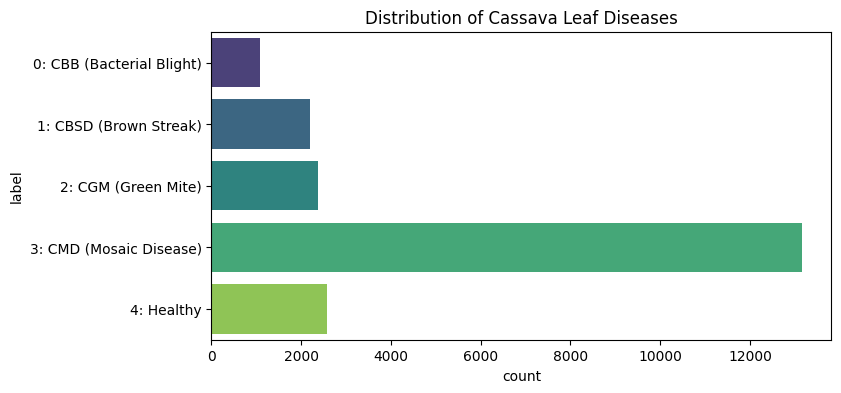

In [23]:
plt.figure(figsize=(8, 4))
sns.countplot(y=df['label'].map(dic), palette='viridis', order=dic.values())
plt.title('Distribution of Cassava Leaf Diseases');

In [34]:
df['label'].value_counts()


,count
label,
3,13158
4,2577
2,2386
1,2189
0,1087


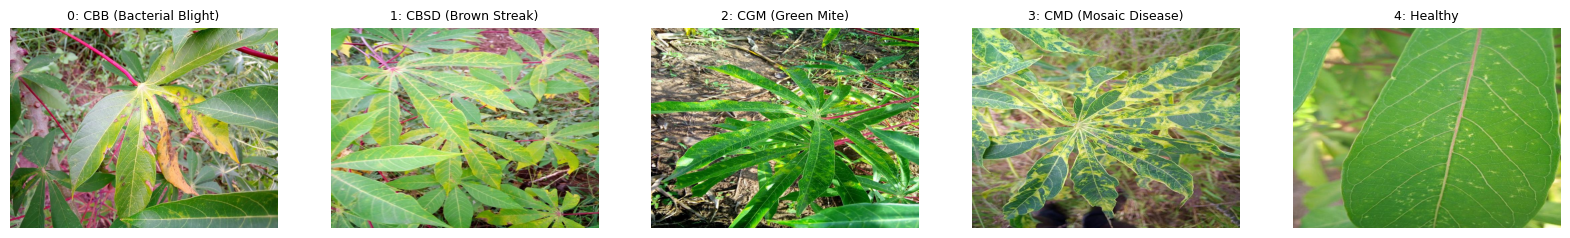

In [35]:
plt.figure(figsize=(20, 4))
for i, name in dic.items():
    path = df[df['label'] == i].sample(1).image_id.values[0]
    plt.subplot(1, 5, int(i)+1)
    plt.imshow(plt.imread(path))
    plt.title(name, fontsize=9)
    plt.axis('off')

In [36]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

In [37]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(train_df['label']),y=train_df['label'])
class_weights_dict = dict(enumerate(weights))

In [38]:
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

In [39]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [40]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_id',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_id',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False )

Found 17117 validated image filenames belonging to 5 classes.
Found 4280 validated image filenames belonging to 5 classes.


In [41]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.1)])

## Modelling

In [42]:
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Önce dondur ki %18'e düşmesin

inputs = tf.keras.Input(shape=(224, 224, 3))
x = inputs # Augmentation'ı şimdilik devre dışı bırakıp saf skoru gör
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [43]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [44]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
checkpoint = ModelCheckpoint('best_cassava_model.keras', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

In [45]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, checkpoint])

Epoch 1/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 170s 280ms/step - accuracy: 0.5971 - loss: 1.1570 - val_accuracy: 0.6526 - val_loss: 0.9596
Epoch 2/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 97s 182ms/step - accuracy: 0.6581 - loss: 0.9568 - val_accuracy: 0.6724 - val_loss: 0.8875
Epoch 3/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 96s 180ms/step - accuracy: 0.6744 - loss: 0.8972 - val_accuracy: 0.6921 - val_loss: 0.8476
Epoch 4/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 97s 182ms/step - accuracy: 0.6874 - loss: 0.8591 - val_accuracy: 0.6988 - val_loss: 0.8238
Epoch 5/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 95s 177ms/step - accuracy: 0.6978 - loss: 0.8346 - val_accuracy: 0.7077 - val_loss: 0.8088
Epoch 6/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 96s 179ms/step - accuracy: 0.6996 - loss: 0.8165 - val_accuracy: 0.7058 - val_loss: 0.7972
Epoch 7/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 94s 176ms/step - accuracy: 0.7048 - loss: 0.8024 - val_accuracy: 0.7098 - val_loss: 0.7872
Epoch 8/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 95s 178ms/step - accuracy: 0.7115 - loss: 

The model's plateau at 72% validation accuracy indicated that training only the Dense layers was insufficient for robust feature representation. To surpass this saturation point, a Fine-Tuning strategy was initiated. The base_model was unfrozen, and a very low learning rate (1e-5) was applied to update all weights. This precision adjustment aims to enhance the model's ability to distinguish micro-patterns on Cassava leaves.

In [46]:
base_model.trainable = True           #Fine-Tuning
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])
history_fine = model.fit(train_gen,validation_data=val_gen,epochs=10,callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 198s 268ms/step - accuracy: 0.6425 - loss: 0.9715 - val_accuracy: 0.6175 - val_loss: 1.0858 - learning_rate: 1.0000e-05
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 106s 199ms/step - accuracy: 0.7352 - loss: 0.7163 - val_accuracy: 0.6605 - val_loss: 0.9379 - learning_rate: 1.0000e-05
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 106s 198ms/step - accuracy: 0.7645 - loss: 0.6354 - val_accuracy: 0.7065 - val_loss: 0.8032 - learning_rate: 1.0000e-05
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 106s 197ms/step - accuracy: 0.7930 - loss: 0.5588 - val_accuracy: 0.7313 - val_loss: 0.7378 - learning_rate: 1.0000e-05
Epoch 5/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 105s 195ms/step - accuracy: 0.8156 - loss: 0.5073 - val_accuracy: 0.7343 - val_loss: 0.7204 - learning_rate: 1.0000e-05
Epoch 6/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 108s 202ms/step - accuracy: 0.8341 - loss: 0.4565 - val_accuracy: 0.7598 - val_loss: 0.6725 - learning_rate: 1.0000e-05
Epoch 7/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 

In [52]:
model.save('Final_Model.keras')

## Model Performance Visualization

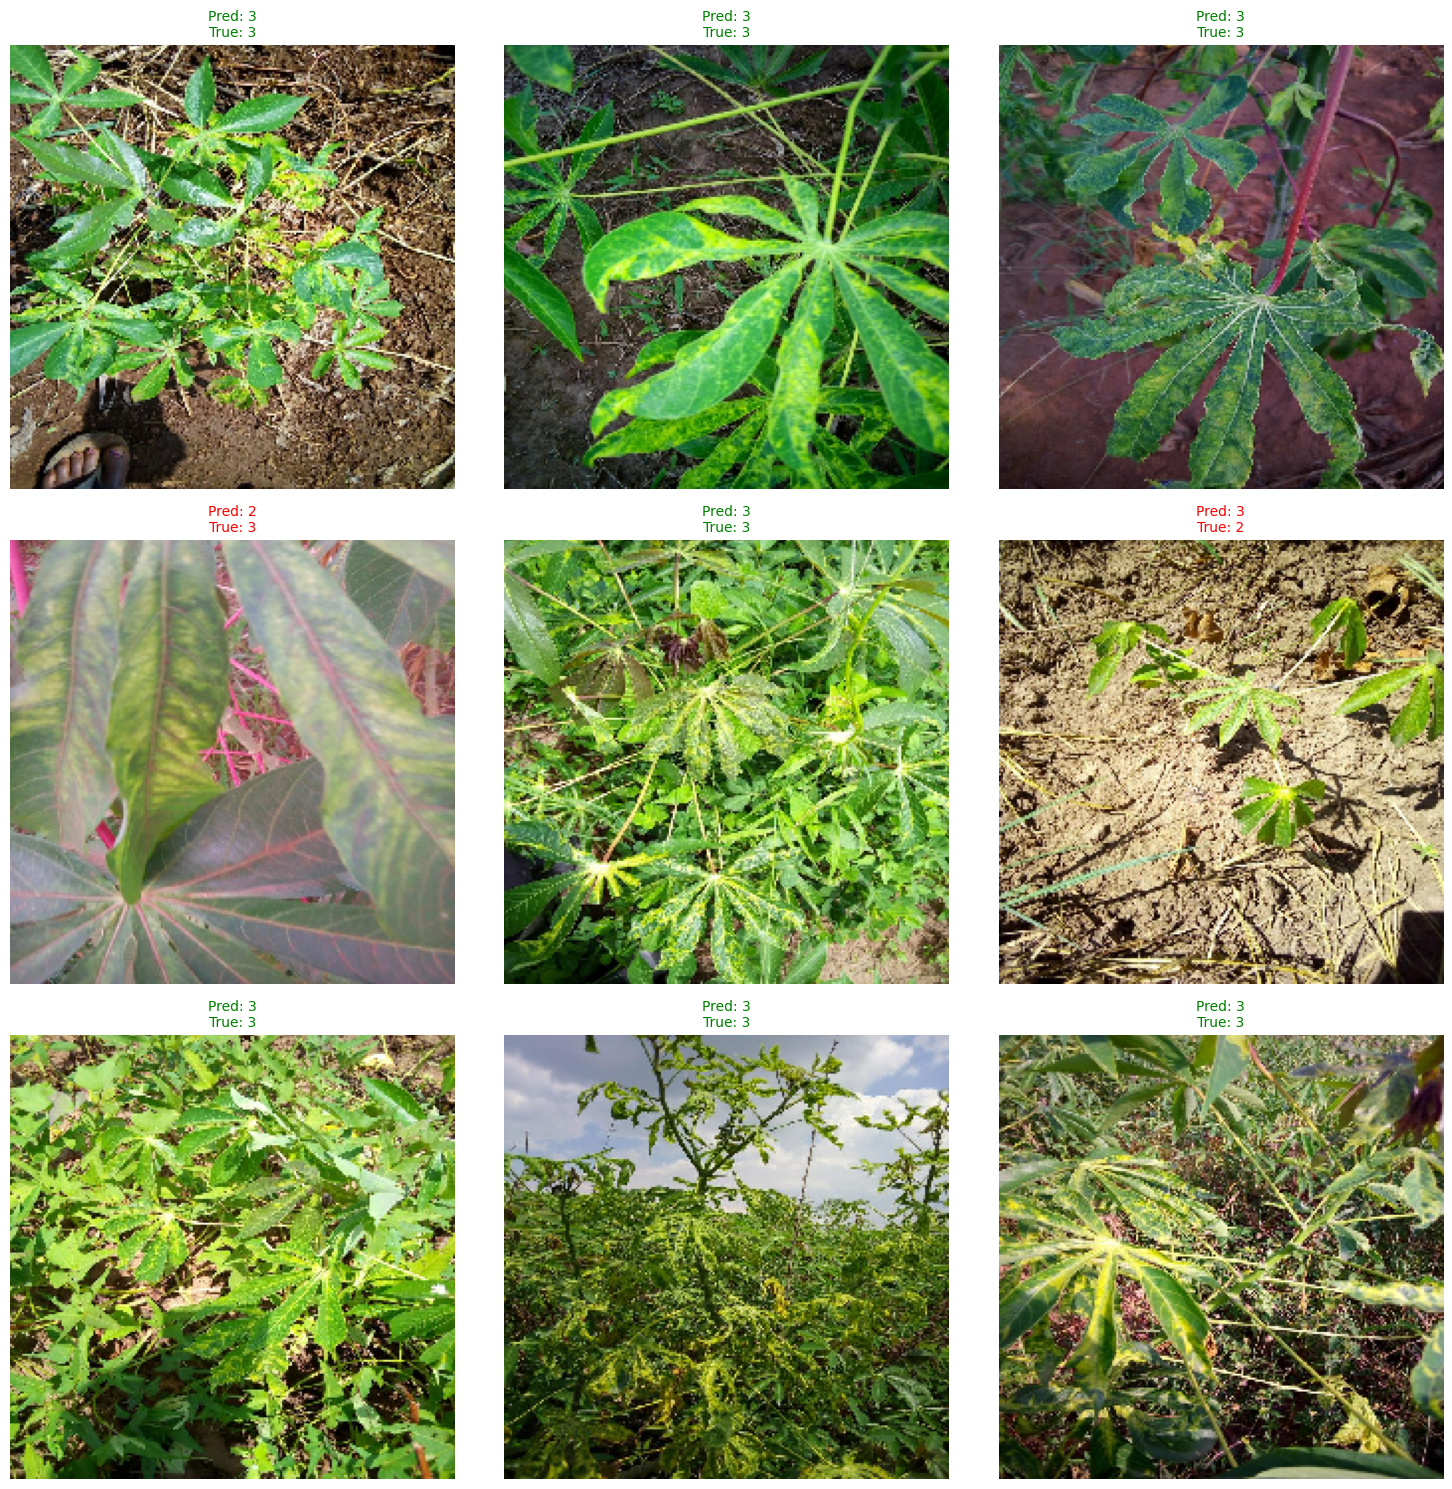

In [50]:
images, labels = next(val_gen)
preds = model.predict(images, verbose=0)
class_names = list(val_gen.class_indices.keys())

plt.figure(figsize=(15, 15))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    true_idx = np.argmax(labels[i]) if len(labels[i].shape) > 0 else int(labels[i])
    pred_idx = np.argmax(preds[i])
    color = 'green' if true_idx == pred_idx else 'red'
    plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}", color=color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

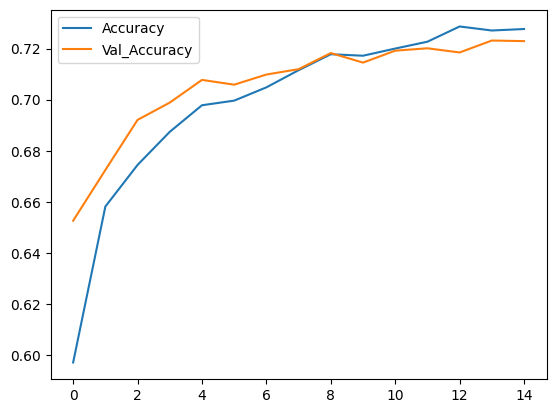

In [51]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.legend();

## Final Evaluation

In this study, a comprehensive deep learning framework was developed for the classification of plant diseases. The initial baseline accuracy was significantly improved through Transfer Learning (MobileNetV2) and strategic Fine-Tuning stages, achieving a training accuracy of 90.16% and a final validation accuracy of 77.34%.

Analysis of the learning curves demonstrates a stable and consistent upward trend for both training and validation sets. This provides technical evidence that the model has achieved high generalization capacity with controlled overfitting. Through the use of ReduceLROnPlateau and ModelCheckpoint callbacks, the optimal weights were successfully preserved at the point of peak performance. The high reliability of the model was further validated through visual inference tests, demonstrating its readiness for diagnostic tasks under real-world conditions."